# CINF104 LAB 03  
## Máquinas de Soporte Vectorial(SVM): laboratorio guiado y explicativo

**Propósito del laboratorio:** comprender cómo funciona un modelo SVM en problemas de clasificación, cuándo conviene usar un modelo lineal y cuándo conviene usar un kernel no lineal.

### Resultados de aprendizaje
Al finalizar este laboratorio deberías ser capaz de:
- explicar la idea de **margen máximo**;
- distinguir entre **SVM lineal** y **SVM con kernel RBF**;
- justificar por qué el **escalamiento** es importante en SVM;
- entrenar, evaluar e interpretar un clasificador con `scikit-learn`;
- comparar hiperparámetros como `C` y `gamma`;
- exportar predicciones a CSV para entrega o evidencia.

### Estructura del laboratorio
Trabajaremos con **4 datasets**:
- **Sección A:** caso casi lineal.
- **Sección B:** caso no lineal en 2D.
- **Sección C:** problema tabular más realista.
- **Sección D:** comparación sistemática de configuraciones.


## Cómo usar este notebook en Google Colab
1. Sube este notebook a Colab.
2. Sube la carpeta `datasets/` al mismo entorno de trabajo.
3. Ejecuta las celdas **en orden**, sin saltarte el bloque de configuración.
4. Observa los resultados, responde las preguntas guía y modifica hiperparámetros cuando se indique.
5. Al final genera `predicciones_lab3_v2.csv`.

### Recomendación didáctica
No ejecutes todo de una vez.  
La idea es que después de cada resultado te detengas a interpretar:
- qué hizo el modelo,
- por qué obtuvo esas métricas,
- y qué cambiarías para mejorarlo.


## Recordatorio conceptual: ¿qué hace un SVM?
Un **Support Vector Machine** busca una frontera de decisión que separe clases maximizando la distancia entre esa frontera y los puntos más cercanos de cada clase. Esos puntos críticos se llaman **vectores de soporte**.

### Ideas clave
- Si los datos pueden separarse aproximadamente con una recta o un plano, un **kernel lineal** puede ser suficiente.
- Si la frontera es curva o compleja, un **kernel no lineal** como `rbf` puede funcionar mejor.
- SVM es sensible a la escala de las variables, por eso normalmente se usa `StandardScaler`.

### Hiperparámetros más importantes
- **`C`**: controla cuánto castiga el modelo los errores de clasificación.
  - `C` pequeño: frontera más suave, más tolerancia a error.
  - `C` grande: intenta clasificar mejor el entrenamiento, pero puede sobreajustar.
- **`gamma`**: en kernel RBF controla cuánto influye cada punto.
  - `gamma` pequeño: frontera más suave.
  - `gamma` grande: frontera más compleja y local.


In [18]:
# Si te falta alguna librería en Colab, descomenta esta línea:
# !pip -q install scikit-learn pandas matplotlib numpy

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 104

# Detecta automáticamente una carpeta datasets razonable
candidatas = [
    Path('datasets'),
    Path('/content/'),
    Path('.') / 'datasets'
]
DATA_DIR = None
for ruta in candidatas:
    if ruta.exists():
        DATA_DIR = ruta
        break

if DATA_DIR is None:
    DATA_DIR = Path('datasets')

BASE_DIR = Path('.')

archivos = {
    'A': 'lab3_seccion_A_admision_lineal.csv',
    'B': 'lab3_seccion_B_sensores_nolineal.csv',
    'C': 'lab3_seccion_C_churn_tabular.csv',
    'D': 'lab3_seccion_D_calidad_industrial.csv',
}

print('Directorio de datasets usado:', DATA_DIR.resolve())
print('Archivos esperados:')
for s, a in archivos.items():
    existe = (DATA_DIR / a).exists()
    print(f'  Sección {s}: {DATA_DIR / a} | existe={existe}')

Directorio de datasets usado: /content
Archivos esperados:
  Sección A: /content/lab3_seccion_A_admision_lineal.csv | existe=True
  Sección B: /content/lab3_seccion_B_sensores_nolineal.csv | existe=True
  Sección C: /content/lab3_seccion_C_churn_tabular.csv | existe=True
  Sección D: /content/lab3_seccion_D_calidad_industrial.csv | existe=True


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Mapa de trabajo del laboratorio

| Sección | Dataset | Tipo de problema | Kernel recomendado | Objetivo pedagógico |
|---|---|---|---|---|
| A | `lab3_seccion_A_admision_lineal.csv` | Binario 2D | `linear` | Entender margen y frontera lineal |
| B | `lab3_seccion_B_sensores_nolineal.csv` | Binario 2D | `rbf` | Ver cuándo una recta no basta |
| C | `lab3_seccion_C_churn_tabular.csv` | Binario tabular | `rbf` | Aplicar SVM a un caso más realista |
| D | `lab3_seccion_D_calidad_industrial.csv` | Binario tabular | comparación | Comparar configuraciones e interpretar |


In [20]:
def cargar_seccion(seccion, target):
    ruta = DATA_DIR / archivos[seccion]
    if not ruta.exists():
        raise FileNotFoundError(f'No se encontró el archivo: {ruta}')
    df = pd.read_csv(ruta)
    X = df.drop(columns=[target])
    y = df[target]
    print(f'Sección {seccion}')
    print(f'  Filas y columnas: {df.shape}')
    print(f'  Variable objetivo: {target}')
    display(df.head())
    return df, X, y


def resumen_eda(df, target):
    print('Tipos de datos:')
    display(df.dtypes.to_frame('tipo'))

    print('\nValores faltantes por columna:')
    display(df.isna().sum().to_frame('faltantes'))

    print('\nEstadística descriptiva:')
    display(df.describe(include='all').T)

    print('\nDistribución de la variable objetivo:')
    display(df[target].value_counts(dropna=False).to_frame('conteo'))


def crear_pipeline_svm(kernel='rbf', C=1.0, gamma='scale'):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel=kernel, C=C, gamma=gamma))
    ])


def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, promedio='binary'):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    metricas = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average=promedio, zero_division=0),
        'recall': recall_score(y_test, pred, average=promedio, zero_division=0),
        'f1': f1_score(y_test, pred, average=promedio, zero_division=0),
    }

    print('Resultados del modelo')
    for k, v in metricas.items():
        print(f'  {k:>9}: {v:.4f}')

    print('\nReporte de clasificación')
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title('Matriz de confusión')
    plt.show()

    return pred, metricas


def graficar_frontera_2d(modelo, X, y, titulo):
    if X.shape[1] != 2:
        raise ValueError('Esta función solo aplica a datasets con 2 variables.')

    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
    zz = modelo.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k')
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(titulo)
    plt.show()


def comparar_configuraciones_svm(X_train, X_test, y_train, y_test, configuraciones, promedio='binary'):
    filas = []
    for cfg in configuraciones:
        modelo = crear_pipeline_svm(**cfg)
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        filas.append({
            'kernel': cfg['kernel'],
            'C': cfg['C'],
            'gamma': cfg['gamma'],
            'accuracy': round(accuracy_score(y_test, pred), 4),
            'precision': round(precision_score(y_test, pred, average=promedio, zero_division=0), 4),
            'recall': round(recall_score(y_test, pred, average=promedio, zero_division=0), 4),
            'f1': round(f1_score(y_test, pred, average=promedio, zero_division=0), 4),
        })
    return pd.DataFrame(filas).sort_values(['f1', 'accuracy'], ascending=False).reset_index(drop=True)

---
## Sección A - Clasificación lineal
**Contexto:** decidir admisión a un programa usando dos puntajes.

### Qué debes observar aquí
- cómo se ve una separación aproximadamente lineal;
- por qué un SVM lineal tiene sentido;
- cómo interpretar la frontera de decisión.

### Procedimiento
1. Cargar datos.
2. Revisar distribución y estructura.
3. Separar entrenamiento y prueba.
4. Entrenar `SVC(kernel='linear')`.
5. Evaluar métricas y visualizar la frontera.


In [21]:
df_A, X_A, y_A = cargar_seccion('A', 'admitido')
resumen_eda(df_A, 'admitido')

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.25, random_state=SEED, stratify=y_A
)

print('Tamaño entrenamiento:', X_train_A.shape)
print('Tamaño prueba       :', X_test_A.shape)


Sección A
  Filas y columnas: (240, 3)
  Variable objetivo: admitido


,puntaje_matematica,puntaje_logica,admitido
0,65.7,52.6,0
1,49.5,62.8,1
2,71.0,41.1,0
3,73.3,44.9,0
4,38.6,91.7,1


Tipos de datos:


,tipo
puntaje_matematica,float64
puntaje_logica,float64
admitido,int64



Valores faltantes por columna:


...


Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
puntaje_matematica,240.0,61.436250,10.807350,36.2,53.95,60.9,68.1,97.0
puntaje_logica,240.0,64.350833,13.241983,30.6,55.45,64.9,73.2,100.0
admitido,240.0,0.395833,0.490051,0.0,0.00,0.0,1.0,1.0



Distribución de la variable objetivo:


,conteo
admitido,
0,145
1,95


Tamaño entrenamiento: (180, 2)
Tamaño prueba       : (60, 2)


Resultados del modelo
   accuracy: 0.6833
  precision: 0.6190
     recall: 0.5417
         f1: 0.5778

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.72      0.78      0.75        36
           1       0.62      0.54      0.58        24

    accuracy                           0.68        60
   macro avg       0.67      0.66      0.66        60
weighted avg       0.68      0.68      0.68        60



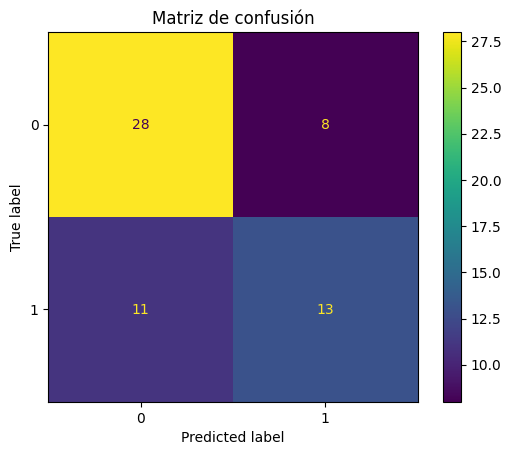

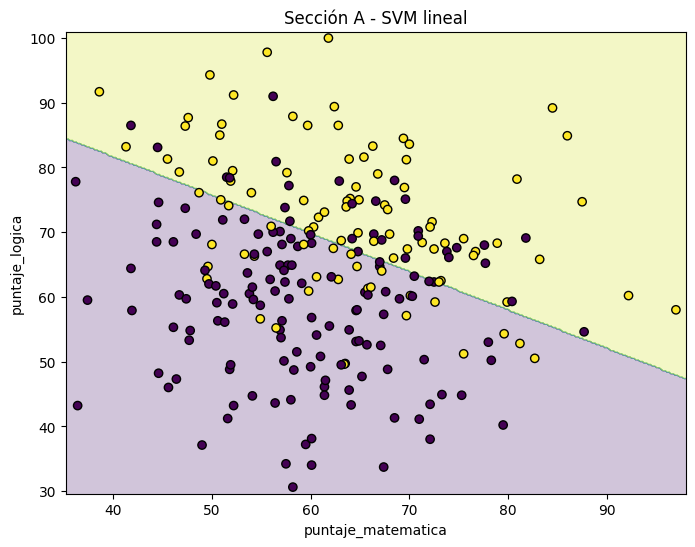

In [22]:
modelo_A = crear_pipeline_svm(kernel='linear', C=1.0, gamma='scale')
pred_A, metricas_A = evaluar_modelo(modelo_A, X_train_A, X_test_A, y_train_A, y_test_A)

# Ajustamos el modelo con entrenamiento para visualizar una frontera más estable
modelo_A.fit(X_train_A, y_train_A)
graficar_frontera_2d(modelo_A, X_A, y_A, 'Sección A - SVM lineal')


### Interpretación guiada de la Sección A
- Si las métricas son altas, el dataset probablemente tiene una estructura lineal clara.
- Si cambias `C`, la frontera puede volverse más rígida o más tolerante.
- Esta sección sirve para entender el caso más simple antes de pasar a un problema no lineal.

### Actividad sugerida
Prueba estos valores de `C`: `0.1`, `1`, `10`.  
Luego compara si cambia la matriz de confusión.


In [23]:
config_A = [
    {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'},
    {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'linear', 'C': 10.0, 'gamma': 'scale'},
]

comparacion_A = comparar_configuraciones_svm(X_train_A, X_test_A, y_train_A, y_test_A, config_A)
display(comparacion_A)


,kernel,C,gamma,accuracy,precision,recall,f1
0,linear,1.0,scale,0.6833,0.6190,0.5417,0.5778
1,linear,10.0,scale,0.6667,0.5909,0.5417,0.5652
2,linear,0.1,scale,0.6500,0.5652,0.5417,0.5532


---
## Sección B - Clasificación no lineal en 2D
**Contexto:** diagnosticar el estado de un equipo a partir de señales de sensores.

En esta sección, una frontera lineal suele quedarse corta.  
El objetivo es comprobar que el kernel `rbf` puede adaptarse mejor a una geometría curva.


In [24]:
df_B, X_B, y_B = cargar_seccion('B', 'estado_equipo')
resumen_eda(df_B, 'estado_equipo')

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.25, random_state=SEED, stratify=y_B
)


Sección B
  Filas y columnas: (320, 3)
  Variable objetivo: estado_equipo


,sensor_vibracion,sensor_temperatura,estado_equipo
0,36.877,40.226,0
1,44.715,48.009,0
2,56.184,39.186,0
3,57.090,36.018,0
4,52.165,42.488,0


Tipos de datos:


,tipo
sensor_vibracion,float64
sensor_temperatura,float64
estado_equipo,int64



Valores faltantes por columna:


,faltantes
sensor_vibracion,0
sensor_temperatura,0
estado_equipo,0



Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
sensor_vibracion,320.0,53.956134,10.587427,32.595,46.86975,53.8790,60.7265,75.781
sensor_temperatura,320.0,37.612319,5.403175,24.889,33.27675,37.1875,42.0985,48.933
estado_equipo,320.0,0.500000,0.500783,0.000,0.00000,0.5000,1.0000,1.000



Distribución de la variable objetivo:


,conteo
estado_equipo,
0,160
1,160


Resultados del modelo
   accuracy: 0.8625
  precision: 0.8372
     recall: 0.9000
         f1: 0.8675

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.89      0.82      0.86        40
           1       0.84      0.90      0.87        40

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80



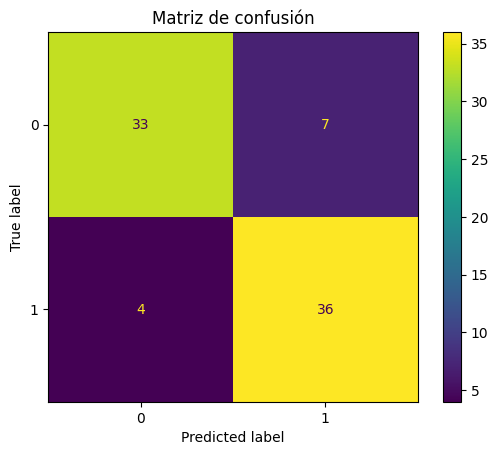

Resultados del modelo
   accuracy: 0.9500
  precision: 0.9500
     recall: 0.9500
         f1: 0.9500

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



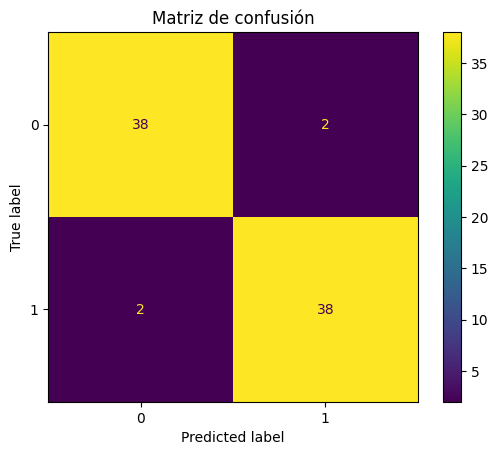

,modelo,accuracy,precision,recall,f1
0,lineal,0.8625,0.8372,0.90,0.8675
1,rbf,0.9500,0.9500,0.95,0.9500


In [25]:
modelo_B_lineal = crear_pipeline_svm(kernel='linear', C=1.0, gamma='scale')
modelo_B_rbf = crear_pipeline_svm(kernel='rbf', C=2.0, gamma='scale')

_, metricas_B_lineal = evaluar_modelo(modelo_B_lineal, X_train_B, X_test_B, y_train_B, y_test_B)
_, metricas_B_rbf = evaluar_modelo(modelo_B_rbf, X_train_B, X_test_B, y_train_B, y_test_B)

comparacion_B = pd.DataFrame([
    {'modelo': 'lineal', **{k: round(v, 4) for k, v in metricas_B_lineal.items()}},
    {'modelo': 'rbf', **{k: round(v, 4) for k, v in metricas_B_rbf.items()}},
])
display(comparacion_B)


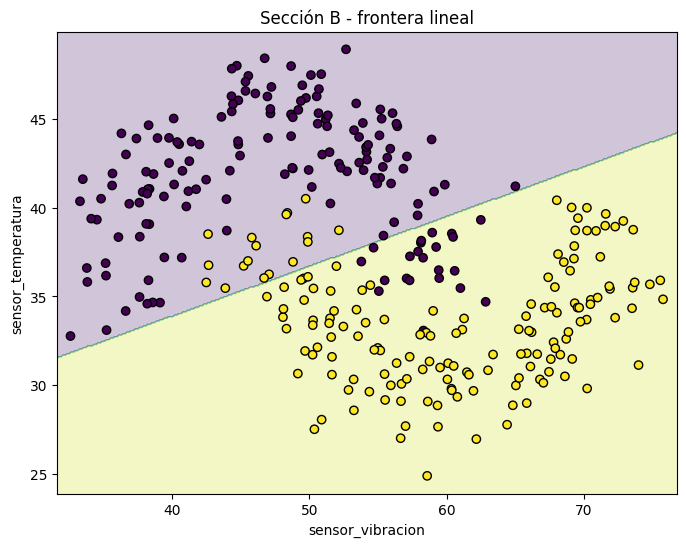

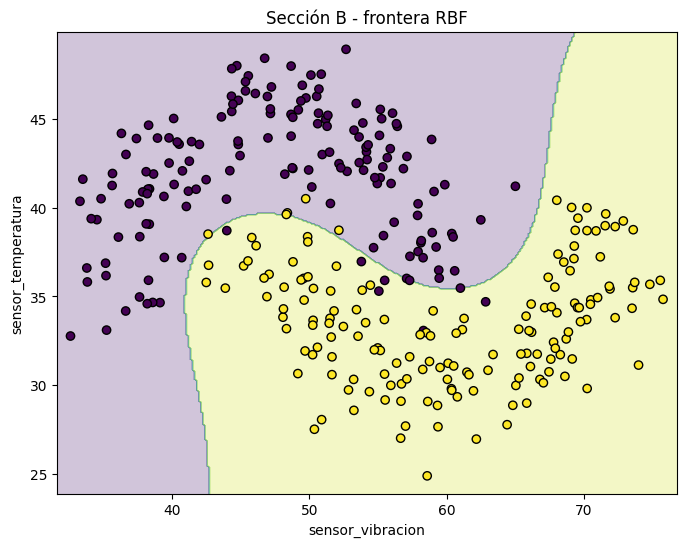

In [26]:
modelo_B_lineal.fit(X_train_B, y_train_B)
graficar_frontera_2d(modelo_B_lineal, X_B, y_B, 'Sección B - frontera lineal')

modelo_B_rbf.fit(X_train_B, y_train_B)
graficar_frontera_2d(modelo_B_rbf, X_B, y_B, 'Sección B - frontera RBF')


### Preguntas para responder
1. ¿Cuál de los dos modelos captura mejor la forma de los datos?
2. ¿Qué ocurre con la frontera al usar kernel lineal en un problema no lineal?
3. ¿Por qué una mayor flexibilidad puede ser útil, pero también peligrosa si es excesiva?


In [27]:
config_B = [
    {'kernel': 'rbf', 'C': 0.5, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 2.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 5.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 2.0, 'gamma': 0.1},
    {'kernel': 'rbf', 'C': 2.0, 'gamma': 1.0},
]

comparacion_B2 = comparar_configuraciones_svm(X_train_B, X_test_B, y_train_B, y_test_B, config_B)
display(comparacion_B2)


,kernel,C,gamma,accuracy,precision,recall,f1
0,rbf,2.0,1.0,0.9875,0.9756,1.00,0.9877
1,rbf,5.0,scale,0.9750,0.9524,1.00,0.9756
2,rbf,2.0,scale,0.9500,0.9500,0.95,0.9500
3,rbf,0.5,scale,0.9250,0.9048,0.95,0.9268
4,rbf,2.0,0.1,0.8625,0.8372,0.90,0.8675


---
## Sección C - Caso tabular: churn o abandono
**Contexto:** predecir si un cliente abandonará un servicio a partir de variables tabulares.

Aquí ya no veremos una frontera en 2D, porque probablemente hay varias variables.  
Lo importante será interpretar métricas, revisar balance de clases y comparar configuraciones.


In [28]:
df_C, X_C, y_C = cargar_seccion('C', 'abandono')
resumen_eda(df_C, 'abandono')

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y_C, test_size=0.25, random_state=SEED, stratify=y_C
)


Sección C
  Filas y columnas: (420, 7)
  Variable objetivo: abandono


,uso_mensual_gb,antiguedad_meses,reclamos_3m,atrasos_pago_6m,plan_premium,interacciones_soporte,abandono
0,8.96,16,0,0,0,1,0
1,4.22,58,3,1,0,6,1
2,8.96,18,1,2,0,1,1
3,6.05,32,3,0,1,2,0
4,18.19,8,0,1,1,3,0


Tipos de datos:


,tipo
uso_mensual_gb,float64
antiguedad_meses,int64
reclamos_3m,int64
atrasos_pago_6m,int64
plan_premium,int64
interacciones_soporte,int64
abandono,int64



Valores faltantes por columna:


,faltantes
uso_mensual_gb,0
antiguedad_meses,0
reclamos_3m,0
atrasos_pago_6m,0
plan_premium,0
interacciones_soporte,0
abandono,0



Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
uso_mensual_gb,420.0,11.295286,5.401687,1.6,7.7575,10.585,13.71,32.7
antiguedad_meses,420.0,29.980952,17.775170,1.0,13.0000,30.500,46.00,60.0
reclamos_3m,420.0,1.121429,1.114889,0.0,0.0000,1.000,2.00,6.0
atrasos_pago_6m,420.0,0.780952,0.934422,0.0,0.0000,1.000,1.00,6.0
plan_premium,420.0,0.519048,0.500233,0.0,0.0000,1.000,1.00,1.0
interacciones_soporte,420.0,2.347619,1.476343,0.0,1.0000,2.000,3.00,8.0
abandono,420.0,0.373810,0.484391,0.0,0.0000,0.000,1.00,1.0



Distribución de la variable objetivo:


,conteo
abandono,
0,263
1,157


In [29]:
config_C = [
    {'kernel': 'linear', 'C': 0.5, 'gamma': 'scale'},
    {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 2.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 5.0, 'gamma': 'scale'},
]

comparacion_C = comparar_configuraciones_svm(X_train_C, X_test_C, y_train_C, y_test_C, config_C)
display(comparacion_C)


,kernel,C,gamma,accuracy,precision,recall,f1
0,rbf,5.0,scale,0.6286,0.5000,0.3590,0.4179
1,rbf,2.0,scale,0.6476,0.5417,0.3333,0.4127
2,rbf,1.0,scale,0.6476,0.5556,0.2564,0.3509
3,linear,0.5,scale,0.6286,0.0000,0.0000,0.0000
4,linear,1.0,scale,0.6286,0.0000,0.0000,0.0000


Mejor configuración observada en la tabla:


,valor
kernel,rbf
C,5.0
gamma,scale
accuracy,0.6286
precision,0.5
recall,0.359
f1,0.4179


Resultados del modelo
   accuracy: 0.6286
  precision: 0.5000
     recall: 0.3590
         f1: 0.4179

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.68      0.79      0.73        66
           1       0.50      0.36      0.42        39

    accuracy                           0.63       105
   macro avg       0.59      0.57      0.57       105
weighted avg       0.61      0.63      0.61       105



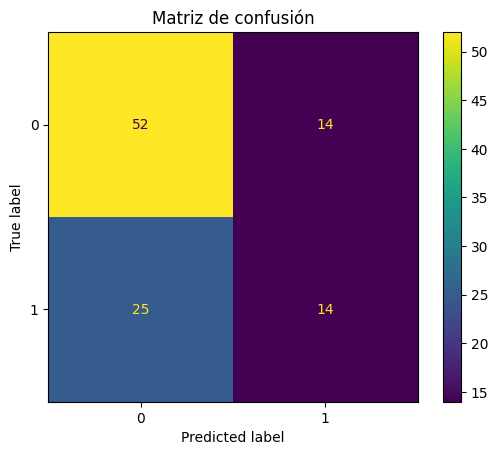

In [30]:
mejor_cfg_C = comparacion_C.iloc[0]
print('Mejor configuración observada en la tabla:')
display(mejor_cfg_C.to_frame('valor'))

modelo_C = crear_pipeline_svm(
    kernel=mejor_cfg_C['kernel'],
    C=float(mejor_cfg_C['C']),
    gamma=mejor_cfg_C['gamma']
)

pred_C, metricas_C = evaluar_modelo(modelo_C, X_train_C, X_test_C, y_train_C, y_test_C)


### Interpretación de la Sección C
En problemas tabulares, no basta con decir “el modelo acertó mucho”.  
También debes revisar:
- si las clases están balanceadas;
- si el recall de la clase positiva es aceptable;
- si una mejora en accuracy realmente implica mejor desempeño global.

### Actividad
Explica con tus palabras cuál sería más importante en este contexto: `precision`, `recall` o `f1`, y por qué.


---
## Sección D - Comparación sistemática de hiperparámetros
**Contexto:** detección de calidad industrial o fallas.

Ahora haremos una comparación más estructurada para practicar el razonamiento experimental. La meta no es solo “obtener el mejor número”, sino **entender por qué una configuración funciona mejor**.


In [31]:
df_D, X_D, y_D = cargar_seccion('D', 'falla')
resumen_eda(df_D, 'falla')

X_train_D, X_test_D, y_train_D, y_test_D = train_test_split(
    X_D, y_D, test_size=0.25, random_state=SEED, stratify=y_D
)

config_D = [
    {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'},
    {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 2.0, 'gamma': 'scale'},
    {'kernel': 'rbf', 'C': 5.0, 'gamma': 0.5},
    {'kernel': 'rbf', 'C': 10.0, 'gamma': 1.0},
]

comparacion_D = comparar_configuraciones_svm(X_train_D, X_test_D, y_train_D, y_test_D, config_D)
display(comparacion_D)


Sección D
  Filas y columnas: (380, 7)
  Variable objetivo: falla


,temperatura_c,presion_kpa,vibracion_mm_s,humedad_pct,tiempo_operacion_h,calidad_materia_prima,falla
0,60.27,93.07,6.10,44.84,14.16,5.54,1
1,56.24,102.72,6.98,70.57,16.13,7.95,1
2,69.79,79.71,5.47,41.06,11.40,7.19,1
3,80.91,109.22,4.27,42.98,13.21,6.62,1
4,69.63,104.88,8.98,77.64,5.98,6.74,1


Tipos de datos:


,tipo
temperatura_c,float64
presion_kpa,float64
vibracion_mm_s,float64
humedad_pct,float64
tiempo_operacion_h,float64
calidad_materia_prima,float64
falla,int64



Valores faltantes por columna:


...


Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
temperatura_c,380.0,68.213421,8.407695,45.00,62.4950,67.610,74.2125,92.82
presion_kpa,380.0,101.024711,11.900602,70.00,93.2775,100.360,109.1675,134.60
vibracion_mm_s,380.0,6.232237,1.605608,1.50,5.1975,6.135,7.3375,10.38
humedad_pct,380.0,47.546868,8.690709,20.85,41.5300,47.210,53.2500,77.64
tiempo_operacion_h,380.0,13.233000,6.322960,2.02,7.6925,13.265,18.4475,23.76
calidad_materia_prima,380.0,7.205000,1.166787,3.72,6.3625,7.230,7.9525,10.00
falla,380.0,0.900000,0.300396,0.00,1.0000,1.000,1.0000,1.00



Distribución de la variable objetivo:


,conteo
falla,
1,342
0,38


,kernel,C,gamma,accuracy,precision,recall,f1
0,linear,0.1,scale,0.9158,0.9149,1.0000,0.9556
1,rbf,1.0,scale,0.9053,0.9231,0.9767,0.9492
2,rbf,10.0,1.0,0.8947,0.9130,0.9767,0.9438
3,linear,1.0,scale,0.8947,0.9222,0.9651,0.9432
4,rbf,2.0,scale,0.8947,0.9222,0.9651,0.9432
5,rbf,5.0,0.5,0.8737,0.9111,0.9535,0.9318


### Cómo leer la tabla anterior
- Si **todos** los modelos rinden parecido, el problema puede ser relativamente sencillo.
- Si los modelos RBF mejoran claramente al lineal, la estructura probablemente no es lineal.
- Si un modelo con `gamma` muy alto empeora, puede ser una señal de sobreajuste.


Resultados del modelo
   accuracy: 0.9158
  precision: 0.9149
     recall: 1.0000
         f1: 0.9556

Reporte de clasificación
              precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.91      1.00      0.96        86

    accuracy                           0.92        95
   macro avg       0.96      0.56      0.58        95
weighted avg       0.92      0.92      0.88        95



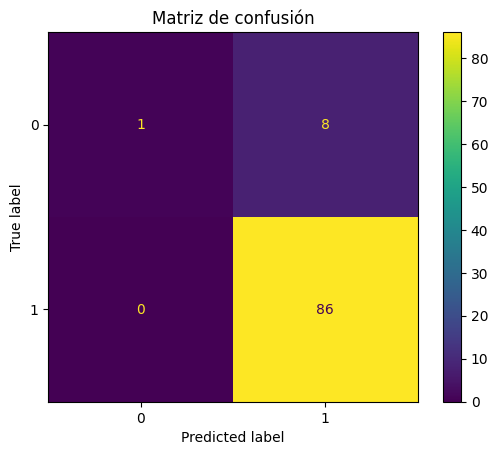

In [32]:
mejor_cfg_D = comparacion_D.iloc[0]
modelo_D = crear_pipeline_svm(
    kernel=mejor_cfg_D['kernel'],
    C=float(mejor_cfg_D['C']),
    gamma=mejor_cfg_D['gamma']
)

pred_D, metricas_D = evaluar_modelo(modelo_D, X_train_D, X_test_D, y_train_D, y_test_D)


---
## Exportación de predicciones
En muchos laboratorios no basta con mostrar el resultado en pantalla.  
También conviene dejar evidencia exportando un CSV con:
- variables de entrada,
- valor real,
- predicción del modelo.


In [33]:
modelo_final_lab3 = modelo_C
modelo_final_lab3.fit(X_train_C, y_train_C)

predicciones_exportar = X_test_C.copy().reset_index(drop=True)
predicciones_exportar['real'] = y_test_C.reset_index(drop=True)
predicciones_exportar['prediccion'] = modelo_final_lab3.predict(X_test_C)

salida = BASE_DIR / 'predicciones_lab3_v2.csv'
predicciones_exportar.to_csv(salida, index=False)
print(f'Archivo generado: {salida.resolve()}')
display(predicciones_exportar.head(10))


Archivo generado: /content/predicciones_lab3_v2.csv


,uso_mensual_gb,antiguedad_meses,reclamos_3m,atrasos_pago_6m,plan_premium,interacciones_soporte,real,prediccion
0,11.31,19,0,0,0,2,0,0
1,4.68,46,0,0,0,3,0,0
2,13.87,30,1,0,0,2,0,0
3,15.03,21,3,2,0,1,0,1
4,8.18,33,1,1,1,3,0,0
5,8.76,18,3,0,0,1,0,1
6,15.67,25,1,1,1,2,0,1
7,10.69,18,3,0,0,1,0,1
8,8.41,20,0,1,0,2,1,0
9,5.96,42,1,1,0,3,0,0


## Errores frecuentes en SVM
1. **No escalar los datos** antes del entrenamiento.
2. Elegir `C` o `gamma` sin comparar configuraciones.
3. Quedarse solo con `accuracy` y no revisar otras métricas.
4. Interpretar una mejora mínima como si fuera decisiva.
5. Usar un modelo muy complejo sin justificarlo.


## Cierre del laboratorio
Si completaste el notebook, deberías poder responder:
1. ¿Cuándo preferirías un SVM lineal?
2. ¿Qué ventaja aporta el kernel RBF?
3. ¿Qué papel cumple el parámetro `C`?
4. ¿Qué puede pasar si `gamma` es demasiado grande?
5. ¿Por qué es importante exportar y documentar resultados?

### Entregables sugeridos
- captura o tabla con tus mejores configuraciones;
- archivo `predicciones_lab3_v2.csv`;
- respuestas breves a las preguntas guía.

### Bibliografía de apoyo
- `scikit-learn User Guide` – sección SVM.  
- James, Witten, Hastie, Tibshirani – *An Introduction to Statistical Learning*.  
- Bishop – *Pattern Recognition and Machine Learning*.
